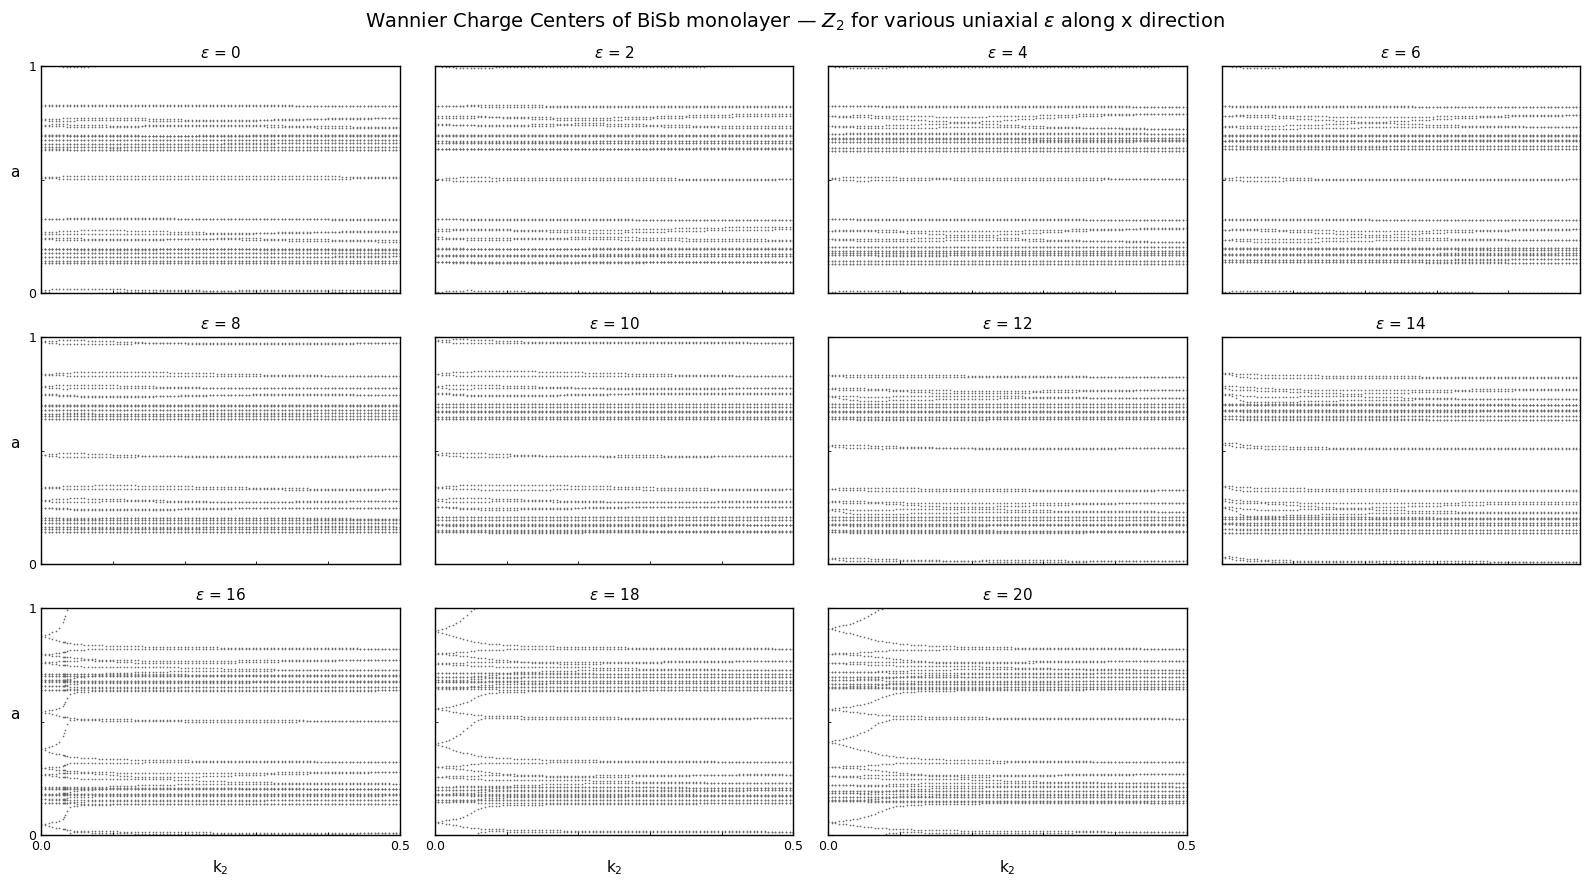

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Config ---
LCOLOR = '#696969'
file_indices = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

n_plots = len(file_indices)
n_cols = 4
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, idx in zip(axes, file_indices):
    try:
        data = np.loadtxt(f"{idx}-wanniercenter3D_Z2_6.dat")
        ax.scatter(data[:, 0] / 2, data[:, 1],
                   s=1.5, color=LCOLOR, marker='o', linewidths=0)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'e{idx} not found',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)

    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.tick_params(axis='x', which='both', direction='in', labelsize=9)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%1.0f'))
    ax.tick_params(axis='y', which='both', direction='in', labelsize=9)

    ax.set_title(rf'$\epsilon$ = {idx}', fontsize=11)

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('a', rotation=0, fontsize=11, labelpad=10)
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel(r'k$_2$', fontsize=11)

    for spine in ax.spines.values():
        spine.set_linewidth(1)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle(r'Wannier Charge Centers of BiSb monolayer — $Z_2$ for various uniaxial $\epsilon$ along x direction', fontsize=14)
plt.tight_layout()
plt.show()

Global DOS range: [2.4431104, 7.9065343]


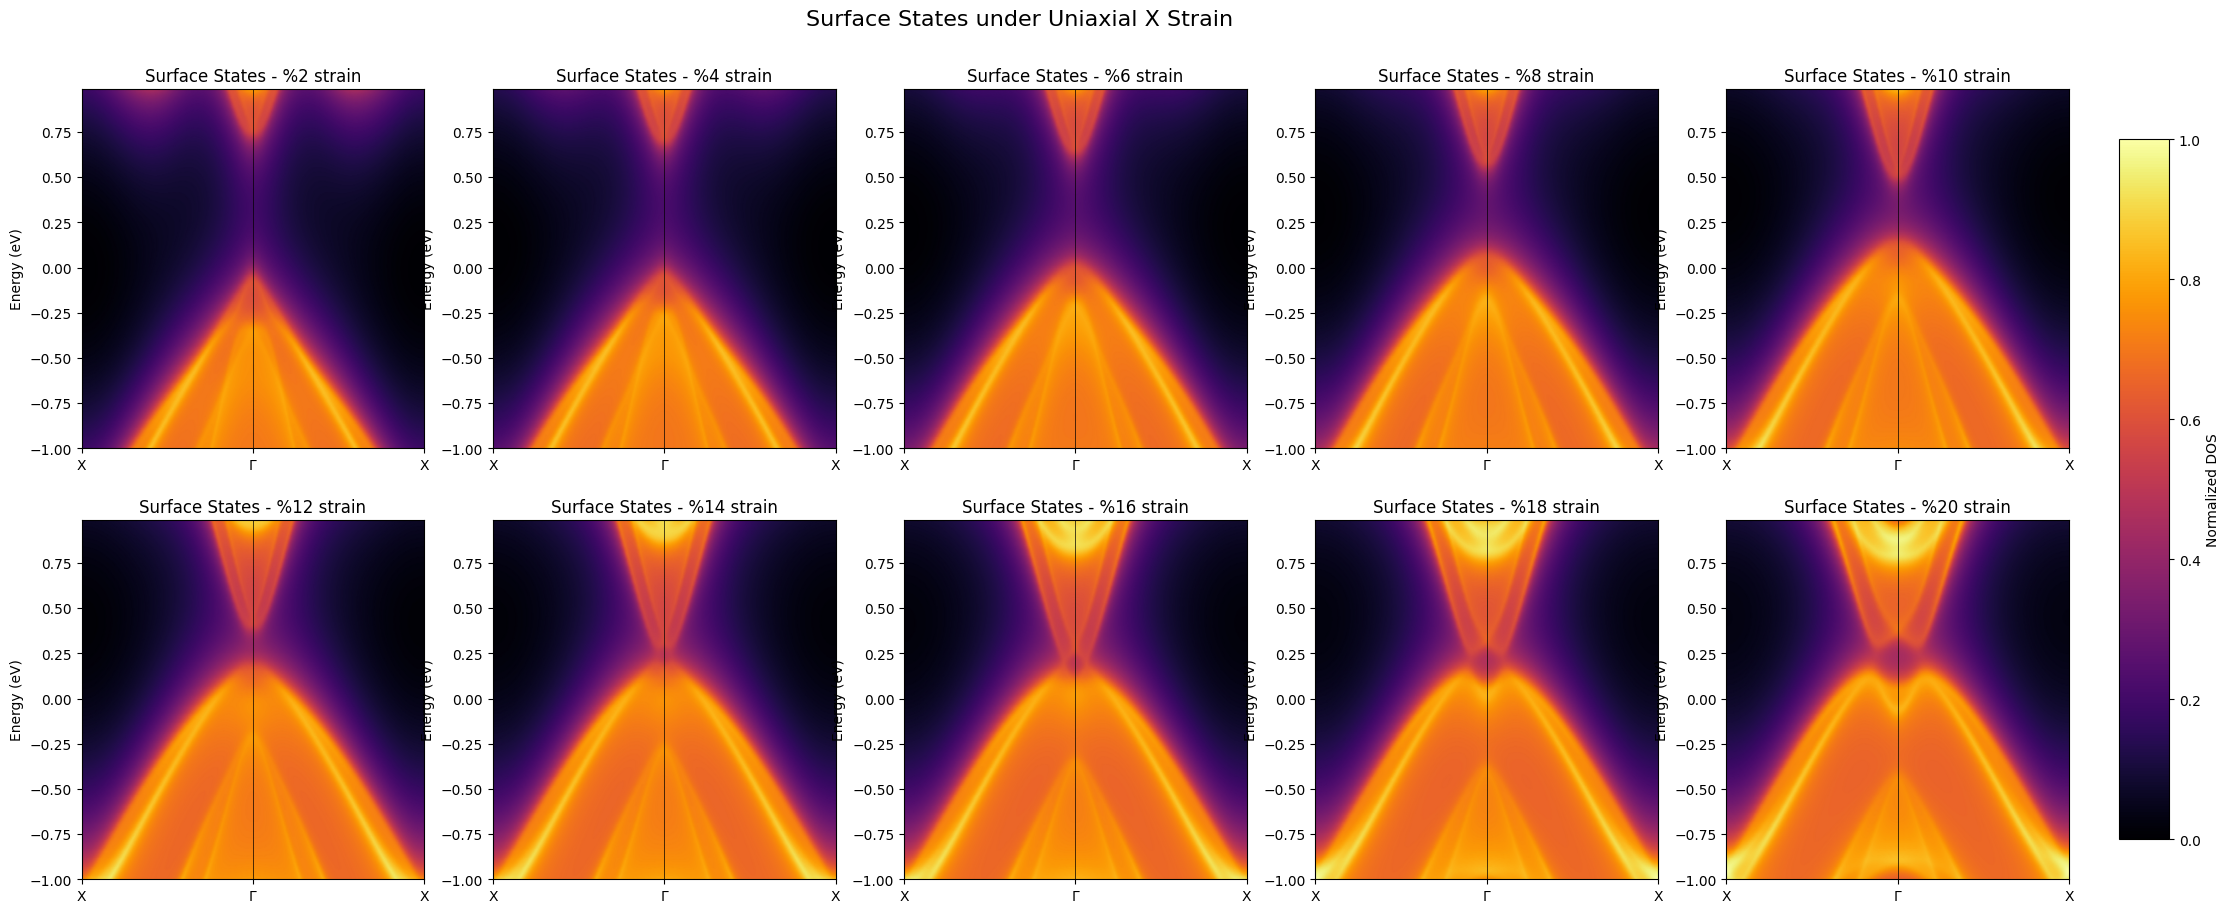

Plot displayed!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import griddata

# Loading all data
data_2 = np.loadtxt("2-dos.dat_bulk")
data_4 = np.loadtxt("4-dos.dat_bulk")
data_6 = np.loadtxt("6-dos.dat_bulk")
data_8 = np.loadtxt("8-dos.dat_bulk")
data_10 = np.loadtxt("10-dos.dat_bulk")
data_12 = np.loadtxt("12-dos.dat_bulk")
data_14 = np.loadtxt("14-dos.dat_bulk")
data_16 = np.loadtxt("16-dos.dat_bulk")
data_18 = np.loadtxt("18-dos.dat_bulk")
data_20 = np.loadtxt("20-dos.dat_bulk")

# Collect all datasets
datasets = [data_2, data_4, data_6, data_8, data_10, data_12, data_14, data_16, data_18, data_20]
labels = ['2', '4', '6', '8', '10', '12', '14', '16', '18', '20']

# Find global min and max of DOS values across all datasets
global_min = min(data[:, 2].min() for data in datasets)
global_max = max(data[:, 2].max() for data in datasets)

print(f"Global DOS range: [{global_min}, {global_max}]")

# Normalize all datasets to [0, 1] range
normalized_datasets = []
for data in datasets:
    data_normalized = data.copy()
    # Min-max normalization
    data_normalized[:, 2] = (data[:, 2] - global_min) / (global_max - global_min)
    normalized_datasets.append(data_normalized)

from matplotlib.colors import LinearSegmentedColormap

# Define custom black-white-yellow colormap
colors = ['#000000', '#FFFFFF', "#FFAE00"]
n_bins = 256  # Discretizes the interpolation into bins
cmap_custom = LinearSegmentedColormap.from_list('black_white_yellow', colors, N=n_bins)

# Function to plot a single dataset
def plot_dos(data, title_suffix, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    x = data[:, 0]
    y = data[:, 1]
    z = data[:, 2]  # Already normalized, no exponential needed
    
    # Create interpolated grid for smooth plotting
    xi = np.linspace(x.min(), x.max(), 400)
    yi = np.linspace(y.min(), y.max(), 400)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), z, (Xi, Yi), method='cubic')
    
    # Plot the data
    im = ax.pcolormesh(Xi, Yi, Zi, cmap='inferno', shading='gouraud', 
                       vmin=0, vmax=1)  # Fixed scale [0, 1]
    
    # Set axis limits
    ax.set_xlim(min(x), max(x))
    
    # Set x-axis ticks and labels
    ax.set_xticks([min(x), (min(x)+max(x))/2, max(x)])
    ax.set_xticklabels(['X', 'Γ', 'X'])
    
    # Set y-axis label
    ax.set_ylabel('Energy (eV)')
    
    # Add vertical line at Gamma point
    ax.axvline(x=(min(x)+max(x))/2, color='black', linewidth=0.5)

    ax.set_title(f"Surface States - %{title_suffix} strain")

    return im

# Create a comparison plot with all datasets
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i, (data, label) in enumerate(zip(normalized_datasets, labels)):
    im = plot_dos(data, label, axes[i])

# Adjust subplot spacing to make room for colorbar on the right
fig.subplots_adjust(right=0.92, top=0.90)  # Added top spacing for title

# Add overall title at the top
fig.suptitle("Surface States under Uniaxial X Strain", fontsize=16, y=0.98)

# Add a shared colorbar on the far right
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='Normalized DOS')
plt.show()

print("Plot displayed!")


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2026-04-10 15:35:42,529                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(30, 101, 5)                                |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

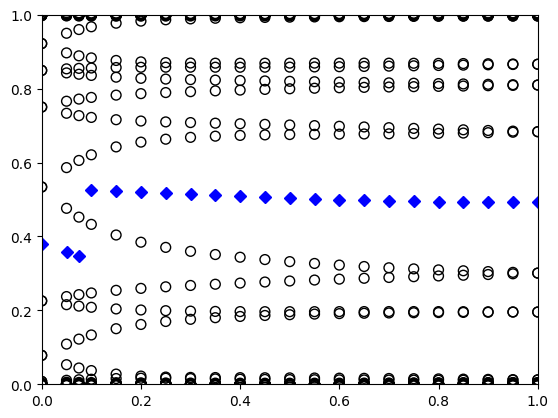

In [5]:
import z2pack, tbmodels
import matplotlib.pyplot as plt

model = tbmodels.Model.from_wannier_files(hr_file='18-wannier90_hr.dat', wsvec_file='18-wannier90_wsvec.dat',occ=40)

system = z2pack.tb.System(model)
result = z2pack.surface.run(system=system, surface=lambda s, t: [s/2 , t, 0.5], num_lines=21,iterator=range(30, 101, 5))

z2pack.plot.wcc(result)
print(z2pack.invariant.z2(result))
plt.show()

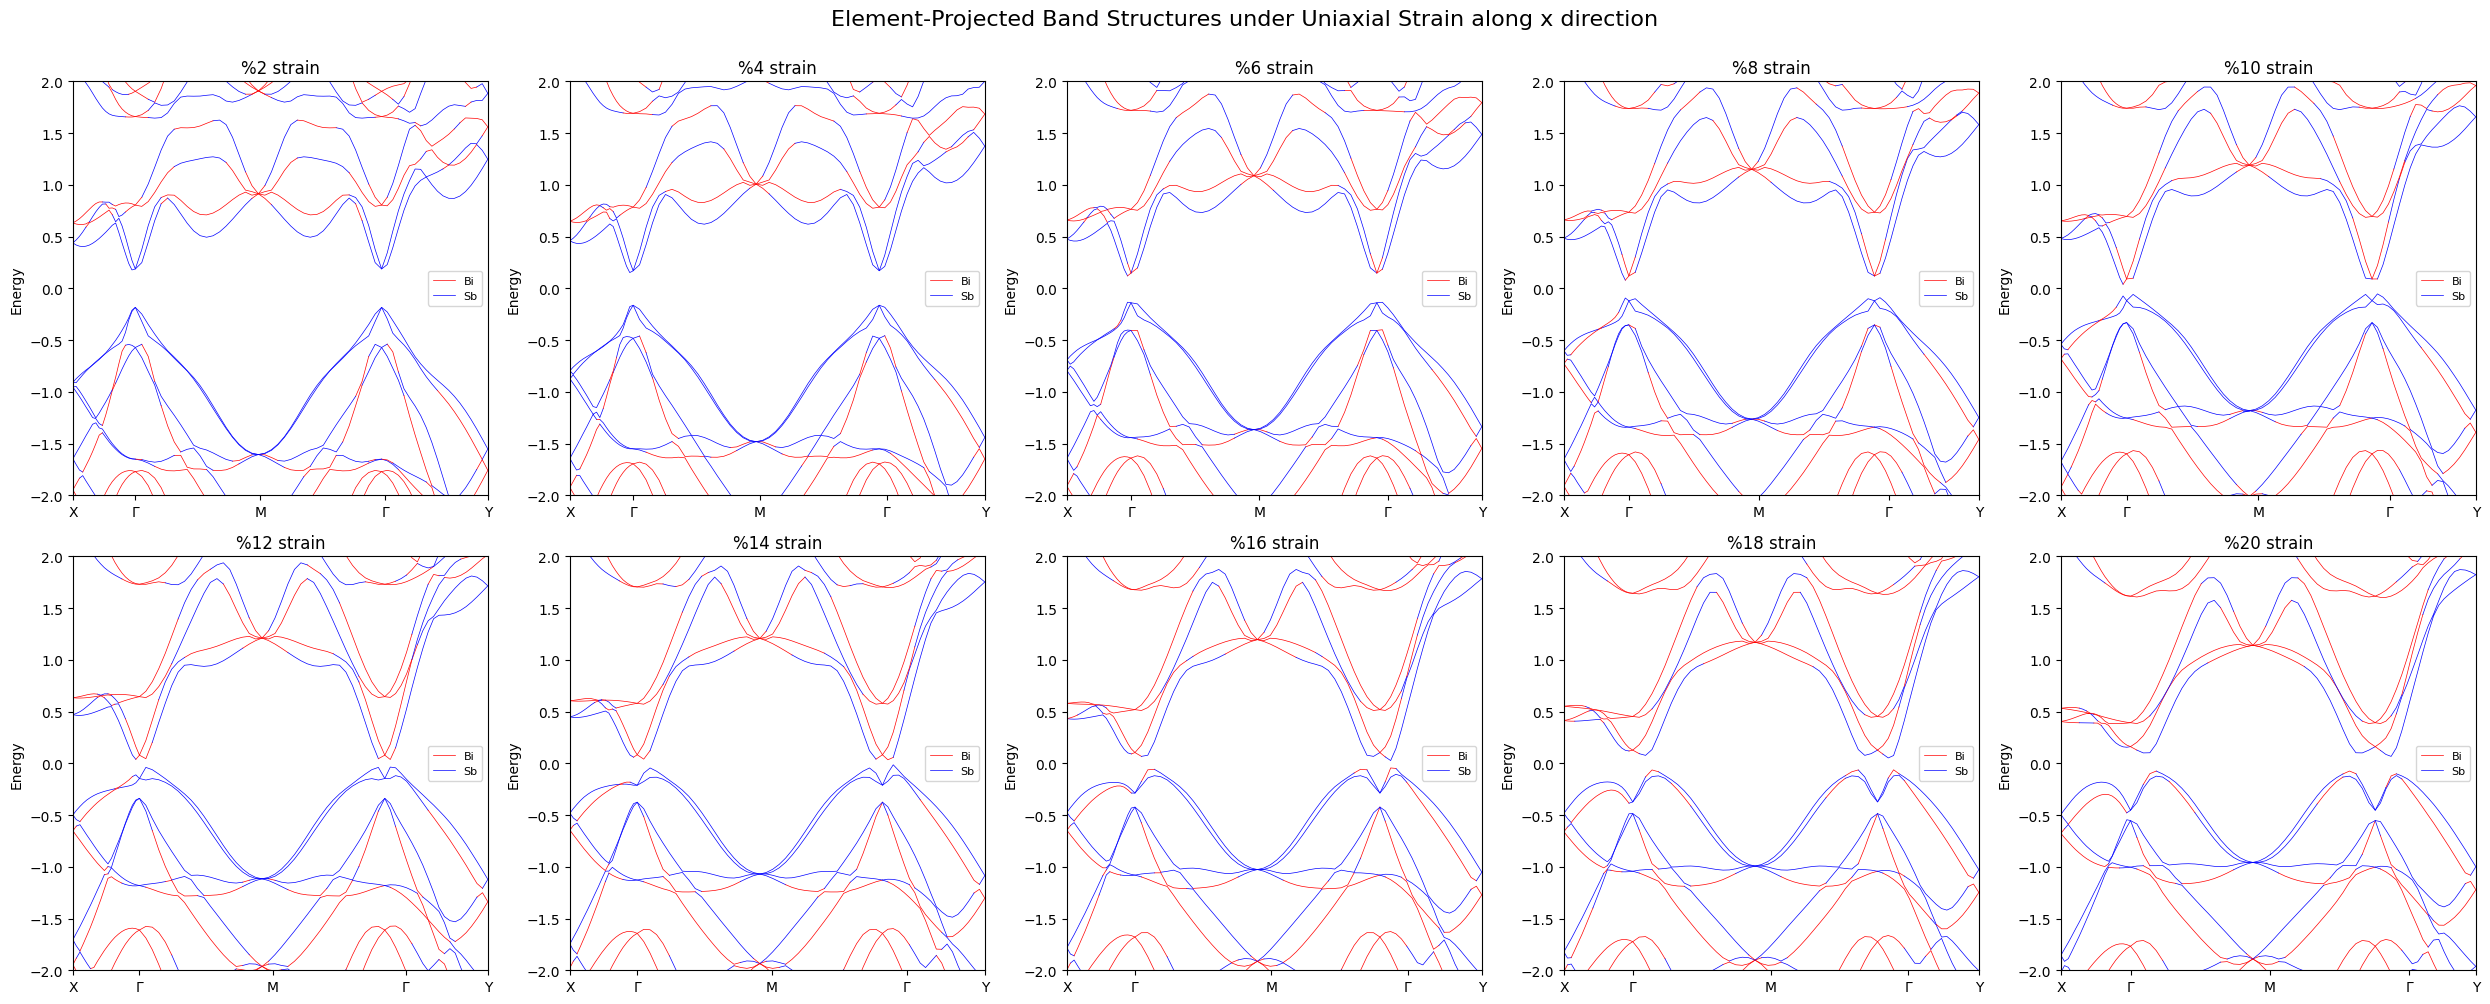

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load all datasets
data_2 = np.loadtxt("2-PBAND_ELEMENTS_SOC.dat")
data_4 = np.loadtxt("4-PBAND_ELEMENTS_SOC.dat")
data_6 = np.loadtxt("6-PBAND_ELEMENTS_SOC.dat")
data_8 = np.loadtxt("8-PBAND_ELEMENTS_SOC.dat")
data_10 = np.loadtxt("10-PBAND_ELEMENTS_SOC.dat")
data_12 = np.loadtxt("12-PBAND_ELEMENTS_SOC.dat")
data_14 = np.loadtxt("14-PBAND_ELEMENTS_SOC.dat")
data_16 = np.loadtxt("16-PBAND_ELEMENTS_SOC.dat")
data_18 = np.loadtxt("18-PBAND_ELEMENTS_SOC.dat")
data_20 = np.loadtxt("20-PBAND_ELEMENTS_SOC.dat")

# Collect all datasets
datasets = [data_2, data_4, data_6, data_8, data_10, data_12, data_14, data_16, data_18, data_20]
labels = ['2', '4', '6', '8', '10', '12', '14', '16', '18', '20']

# Define elements and their corresponding columns
element_names = ['Bi', 'Sb']  # Adjust as needed
element_columns = [2, 3]  # Adjust as needed
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

# High symmetry points
high_sym_points = [0, 0.425, 1.276, 2.127]
high_sym_labels = ['X', 'Γ', 'M', 'Γ', 'Y']

# Create figure with subplots (2 rows, 4 columns to accommodate 7 plots)
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

# Plot each dataset
for idx, (elemented_data, label) in enumerate(zip(datasets, labels)):
    ax = axes[idx]
    
    # Find which element is dominant at each k-point
    dominant_elements = np.argmax(elemented_data[:, element_columns], axis=1)
    
    # Find where the dominant element changes
    color_changes = np.diff(dominant_elements)
    change_indices = np.where(color_changes != 0)[0] + 1
    
    # Add start and end indices
    segment_indices = np.concatenate(([0], change_indices, [len(elemented_data)]))
    
    # Keep track of which elements have been labeled
    labeled_elements = set()
    
    # Plot each segment
    for i in range(len(segment_indices) - 1):
        start = segment_indices[i]
        end = segment_indices[i + 1]
        
        dominant_idx = dominant_elements[start]
        color = colors[dominant_idx]
        elem_label = element_names[dominant_idx]
        
        # Only add label for the first occurrence of each element
        if elem_label not in labeled_elements:
            ax.plot(elemented_data[start:end+1, 0], elemented_data[start:end+1, 1], 
                    color=color, label=elem_label, linewidth=0.5)
            labeled_elements.add(elem_label)
        else:
            ax.plot(elemented_data[start:end+1, 0], elemented_data[start:end+1, 1], 
                    color=color, linewidth=0.5)
    
    # Formatting for each subplot
    ax.set_xticks(high_sym_points + [max(elemented_data[:,0])])
    ax.set_xticklabels(high_sym_labels)
    ax.set_xlim(min(elemented_data[:,0]), max(elemented_data[:,0]))
    ax.set_ylim(-2, 2)
    ax.set_title(f'%{label} strain')
    ax.set_ylabel('Energy')
    ax.legend(loc='best', fontsize=8)


plt.tight_layout()
plt.suptitle("Element-Projected Band Structures under Uniaxial Strain along x direction", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

55


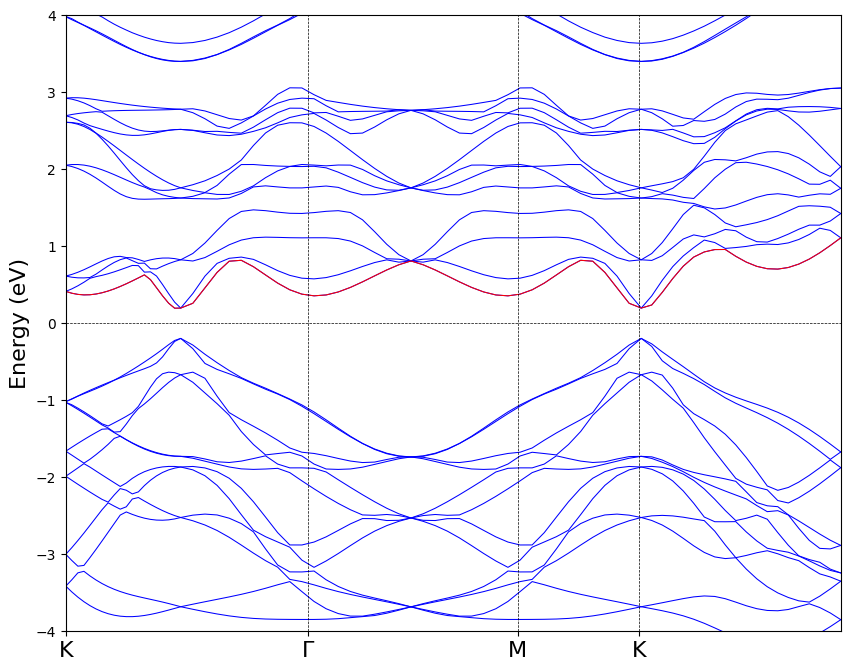

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('0-REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0,0.896,1.671,2.119,3.015]  
high_symmetry_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=0.75)

plt.plot(k, bands[:, 40], color='red', lw=0.75)

plt.axhline(0, color='black', linestyle='--', lw=0.5)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)


plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)

plt.ylabel('Energy (eV)', fontsize=16)
plt.ylim(-4, 4)
plt.xlim(min(k), max(k))
plt.show()